# TRABAJO Parte 2: AIA_2025-2026

# Nombre y DNI del alumno/a 1: Fernando Reguera Bueno 47562744D
# Nombre y DNI del alumno/a 2: Jeremias Josue Pluas Charcopa

# Transfer Learning con CNNs - Dataset: Flowers

La idea de este trabajo es familiarizarnos con dos situaciones muy habituales en la actividad real de un "Machine Learning Engineer":

1.   En primer lugar, con una de las técnicas más potentes asociadas con las redes neuronales: el **Transfer Learning**. Dado que las redes neuronales, para resolver un problema, capturan en su estructura de capas y pesos una representación jerárquica del problema.
Entonces..., ¿por que no aprovechar ese conocimiento obtenido, para resolver otro problema diferente?

2.  En segundo lugar, con la **busqueda de información sobre conceptos nuevos**. En este caso, los dos primeros modelos a implementar los hemos trabajado en clase. No así el Transfer Learning, y por tanto, debereis buscar vosotros mismos como hacer lo que se pide para el Modelo 3.

En este trabajo vamos intentar resolver un problema de clasificación sobre un dataset propuesto por Tensorflow en 2019 conocido como "flowers". Este conjunto está formado por 3670 imágenes de flores pertenecientes a 5 clases diferentes. Para ello implementaremos 3 modelos:

*   Modelo 1: implementación de una CNN básica.
*   Modelo 2: es una evolución del modelo anterior, aplicando técnicas que reduzcan el overfitting.
*   Modelo 3: rompemos la barrera de tener que seguir complicando nuestro modelo y se pide aplicar transfer learning utilizando un pre-trained model.

# a) Carga de datos

In [8]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pathlib
import os
import glob
import shutil
tf.__version__

'2.21.0'

In [9]:
import warnings
warnings.filterwarnings('ignore')

Descargamos el dataset que pone a nuestra disposición Tensorflow.

In [10]:
_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

zip_file = tf.keras.utils.get_file(origin=_URL,
                                   fname="flower_photos.tgz",
                                   extract=True,
                                   )

base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


Tras completar la descarga, debemos tener la siguiente estructura de directorios:  

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>~/.keras/datasets/flower_photos_extracted/flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

Creamos una lista con el nombre de las 5 clases.

In [11]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

In [12]:
base_dir = os.path.expanduser("~/.keras/datasets/flower_photos_extracted/flower_photos/")

Preparamos variables con las rutas de los diferentes directorios a crear:

In [13]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

daisy_dir = os.path.join(train_dir, 'daisy')
dandelion_dir = os.path.join(train_dir, 'dandelion')
roses_dir = os.path.join(train_dir, 'roses')
sunflowers_dir = os.path.join(train_dir, 'sunflowers')
tulips_dir = os.path.join(train_dir, 'tulips')

In [14]:
SPLIT_RATIO=0.8

for cl in classes:
    img_path = os.path.join(base_dir, cl)
    images = glob.glob(img_path + '/*.jpg')
    print("{}: {} Imagenes".format(cl, len(images)))

    num_train = int(round(len(images)*SPLIT_RATIO))
    train, val = images[:num_train], images[num_train:]

    if not os.path.exists(os.path.join(base_dir, 'train', cl)):
        os.makedirs(os.path.join(base_dir, 'train', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'train', cl))
        os.makedirs(os.path.join(base_dir, 'train', cl))

    if not os.path.exists(os.path.join(base_dir, 'val', cl)):
        os.makedirs(os.path.join(base_dir, 'val', cl))
    else:
        shutil.rmtree(os.path.join(base_dir, 'val', cl))
        os.makedirs(os.path.join(base_dir, 'val', cl))

    for t in train:
        shutil.move(t, os.path.join(base_dir, 'train', cl))

    for v in val:
        shutil.move(v, os.path.join(base_dir, 'val', cl))

roses: 641 Imagenes
daisy: 633 Imagenes
dandelion: 898 Imagenes
sunflowers: 699 Imagenes
tulips: 799 Imagenes


**Tarea 1: Muestre el nombre de dos ficheros cualquiera en alguna de esas rutas**

In [15]:
# Mostramos dos ficheros de la carpeta de rosas en train
ficheros_roses = os.listdir(roses_dir)
print("Dos imágenes en la carpeta de rosas (train):")
print(ficheros_roses[0])
print(ficheros_roses[1])

Dos imágenes en la carpeta de rosas (train):
10090824183_d02c613f10_m.jpg
102501987_3cdb8e5394_n.jpg


Es decir, la clase a la que pertenece cada imagen no viene dada por el nombre del fichero sino por el directorio en el que se encuentra almacenada.

**Tarea 2: Muestra el número de imágenes de train que tenemos de cada clase**

In [16]:
print("Imágenes de entrenamiento por clase:")
for cl in classes:
    ruta = os.path.join(train_dir, cl)
    n = len(os.listdir(ruta))
    print(f"  {cl}: {n} imágenes")

Imágenes de entrenamiento por clase:
  roses: 513 imágenes
  daisy: 506 imágenes
  dandelion: 718 imágenes
  sunflowers: 559 imágenes
  tulips: 639 imágenes


# b) Visualización del dataset

**Tarea 3: Muestra 3 imágenes de cada una de las clases, el título de la imagen será el shape del array de numpy asociado a la imagen**

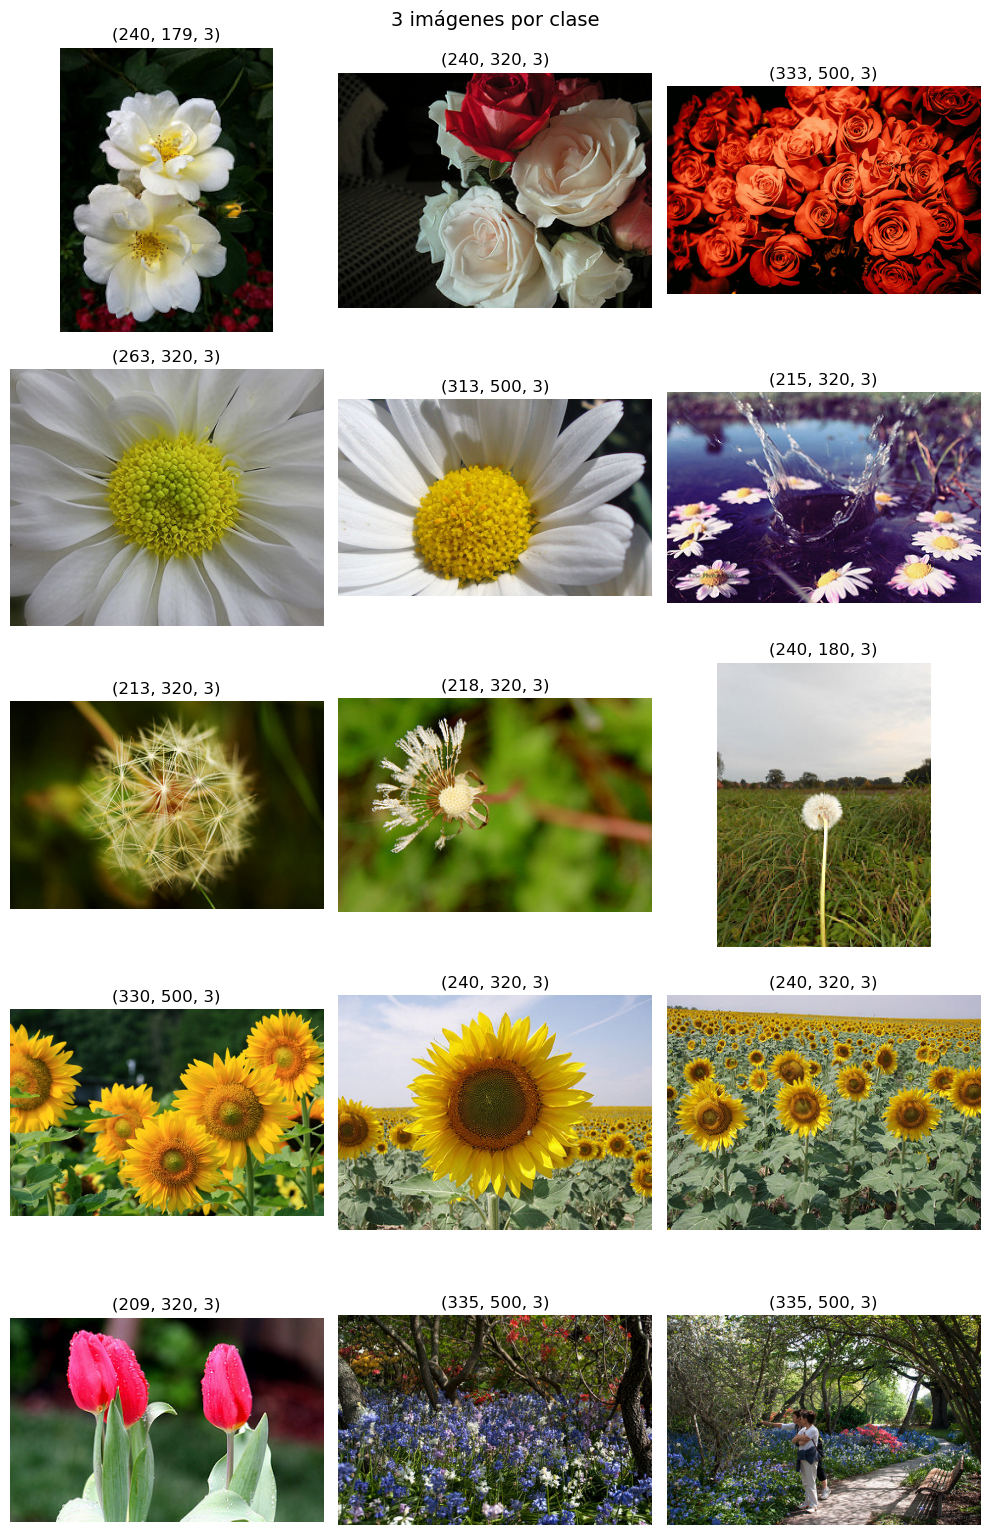

In [17]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(5, 3, figsize=(10, 16))

for i, cl in enumerate(classes):
    ruta_clase = os.path.join(train_dir, cl)
    imagenes = os.listdir(ruta_clase)[:3]
    for j, img_nombre in enumerate(imagenes):
        img = mpimg.imread(os.path.join(ruta_clase, img_nombre))
        axes[i, j].imshow(img)
        axes[i, j].set_title(str(img.shape))
        axes[i, j].axis('off')

plt.suptitle('3 imágenes por clase', fontsize=14)
plt.tight_layout()
plt.show()

# c) Modelo 1: CNN básica (objetivo: accuracy_valid > 60%)


Implemente una red convolucional para resolver el problema de clasificación. Para ello se sugiere una CNN con 3 capas convolucionales + pooling con la siguiente estructura:

Bloque de procesamiento de imagen:
1.   32 kernels -> 64 kernels -> 96 kernels
2.   kernels de 3x3.
3.   Stride = 1 y padding = SI.
4.   Función de activación ReLU.
5.   Maxpooling de 2x2 con stride clásico de 2 pixeles.
6.   Igualamos el tamaño de todas las imágenes a 150 x 150.

Bloque de decisión:
7.   Capa densa de 512 neuronas.
8.   Capa densa de salida.

**Tarea 4: Define un modelo con la estructura anterior**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

IMG_SIZE = 150
NUM_CLASSES = 5

model1 = Sequential([
    # Bloque 1: 32 filtros
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque 2: 64 filtros
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque 3: 96 filtros
    Conv2D(96, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque de decisión
    Flatten(),
    Dense(512, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

**Tarea 5: Indica el shape de la imagen antes y después de cada capa de la red. Explica cómo has obtenido dichos valores**

El tamaño de entrada es **(150, 150, 3)**. Con padding='same' y stride=1, las capas convolucionales no cambian el alto ni el ancho. El maxpooling de 2x2 con stride=2 divide por 2 cada dimensión espacial (redondeando hacia abajo).

Los parámetros de cada capa conv se calculan como: `n_filtros * (kernel_h * kernel_w * canales_entrada + 1)`

| Capa | Shape a la salida | # parámetros |
|:-----|:-----------------:|:------------:|
| Input | (150, 150, 3) | 0 |
| Conv_1 (32 filtros 3x3) | (150, 150, 32) | 32*(3*3*3+1) = **896** |
| Pool_1 (2x2) | (75, 75, 32) | 0 |
| Conv_2 (64 filtros 3x3) | (75, 75, 64) | 64*(3*3*32+1) = **18.496** |
| Pool_2 (2x2) | (37, 37, 64) | 0 |
| Conv_3 (96 filtros 3x3) | (37, 37, 96) | 96*(3*3*64+1) = **55.392** |
| Pool_3 (2x2) | (18, 18, 96) | 0 |
| Flatten | (31.104,) | 0 |
| Densa_1 (512) | (512,) | 31104*512+512 = **15.925.760** |
| Densa_salida (5) | (5,) | 512*5+5 = **2.565** |

El Pool_2 da 37 porque floor(75/2)=37. El Pool_3 da 18 porque floor(37/2)=18. El flatten es 18\*18\*96 = 31.104.

**Tarea 6: Compara el resultado con un summary() del modelo**


In [19]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 7: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 60%.**

* Utilice el optimizador que considere más adecuado.
*   Recuerda que si no se realiza conversión a One-Hot de la etiqueta a predecir, debes utilizar como función de error `SparseCategoricalCrossentropy`.
*   Considera un learning rate en el entorno de 0.001.
*   En el caso de los generators utiliza `class_mode='sparse'`.
*   Puedes utilizar p.e. un `batch_size = 100`.

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalizamos los píxeles al rango [0,1]
datagen_train = ImageDataGenerator(rescale=1.0/255)
datagen_val   = ImageDataGenerator(rescale=1.0/255)

train_generator = datagen_train.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=100,
    class_mode='sparse'
)

val_generator = datagen_val.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=100,
    class_mode='sparse'
)

model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history1 = model1.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3659 - loss: 1.5298 - val_accuracy: 0.5333 - val_loss: 1.1314
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5543 - loss: 1.0732 - val_accuracy: 0.6027 - val_loss: 1.0291
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6392 - loss: 0.9349 - val_accuracy: 0.6503 - val_loss: 0.8997
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6889 - loss: 0.8296 - val_accuracy: 0.6735 - val_loss: 0.8917
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7411 - loss: 0.7076 - val_accuracy: 0.6884 - val_loss: 0.8441
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7727 - loss: 0.5999 - val_accuracy: 0.6789 - val_loss: 0.8299
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.8405 - loss: 0.4593 - val_accuracy: 0.6925 - val_loss: 0.9083
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━

**Tarea 8: Muestra la evolución de la función de error (train y valid) durante el entrenamiento. Explica qué problema presenta el modelo que hemos entrenado.**

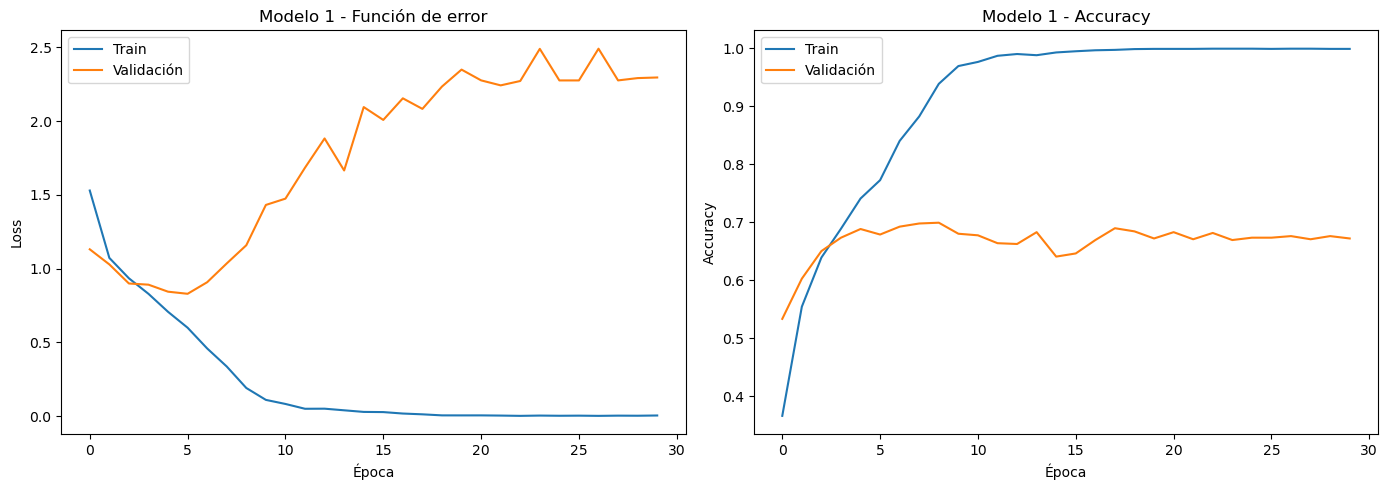

Accuracy final en validación: 0.6721


In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history1.history['loss'], label='Train')
ax1.plot(history1.history['val_loss'], label='Validación')
ax1.set_title('Modelo 1 - Función de error')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history1.history['accuracy'], label='Train')
ax2.plot(history1.history['val_accuracy'], label='Validación')
ax2.set_title('Modelo 1 - Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Accuracy final en validación: {history1.history['val_accuracy'][-1]:.4f}")

**Análisis del modelo 1:**

El modelo presenta un claro problema de **overfitting** (sobreajuste). Se puede ver claramente en las gráficas: la pérdida en entrenamiento sigue bajando con las épocas, mientras que la pérdida en validación se estanca o incluso empieza a subir pasadas unas pocas épocas. Lo mismo pasa con el accuracy: en train sigue mejorando pero en validación se queda bastante por debajo.

Esto ocurre porque el modelo tiene demasiada capacidad (15 millones de parámetros solo en la primera capa densa) para el tamaño del dataset que tenemos (~3000 imágenes de entrenamiento). El modelo acaba memorizando los ejemplos de entrenamiento en lugar de aprender características generales de las flores.

# d) Modelo 2: reducción del overfitting (objetivo: accuracy_valid > 70%)

Para mejorar el accuracy del modelo, vamos a incorporar las dos técnicas más habituales de reducción del overfitting:

    * drop-out
    * data augmentation
    

**Tarea 9: Explica en qué consisten y qué utilidad tienen para nuestro problema**

**Dropout:** durante el entrenamiento, en cada paso se desactivan aleatoriamente un porcentaje de neuronas (se ponen a 0). Esto obliga a la red a no depender demasiado de ninguna neurona concreta, lo que hace que aprenda representaciones más robustas y distribuidas. En nuestro caso ayuda porque tenemos pocas imágenes y la capa densa de 512 neuronas tiende a sobreajustar.

**Data Augmentation:** en lugar de usar siempre las mismas imágenes, en cada época aplicamos transformaciones aleatorias (rotaciones, flips, zoom, etc.) generando versiones ligeramente distintas de cada imagen. Así artificialmente aumentamos el tamaño efectivo del dataset. Para clasificar flores tiene mucho sentido porque:
- Una flor sigue siendo la misma clase si la vemos rotada o desde otro ángulo
- El zoom simula imágenes tomadas a distintas distancias
- El flip horizontal es natural (las flores no tienen una orientación privilegiada)
- Pequeños desplazamientos simulan que la flor no está siempre centrada en la foto

**Tarea 10: Construye un nuevo modelo 2 incorporando (en el modelo 1 anterior) el dropout adecuado**

In [22]:
model2 = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque 3
    Conv2D(96, (3, 3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Bloque de decisión con dropout para reducir overfitting
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),   # desactivamos el 50% de las neuronas durante el entrenamiento
    Dense(NUM_CLASSES, activation='softmax')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 31104)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    15,925,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,003,109 (61.05 MB)

 Trainable params: 16,003,109 (61.05 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 11: Explica qué tipos de augmentation vas a considerar y qué utilidad tienen en nuestro problema de clasificación**

Para este dataset de flores vamos a usar las siguientes transformaciones:

- **rotation_range=40**: rotaciones de hasta 40 grados. Las flores pueden aparecer en cualquier orientación en una foto.
- **width_shift_range=0.2 / height_shift_range=0.2**: desplazamientos horizontales y verticales de hasta el 20% del tamaño. Simula que la flor no está siempre centrada en el encuadre.
- **shear_range=0.2**: ligera deformación de perspectiva, como cuando la foto se toma desde un ángulo.
- **zoom_range=0.2**: zoom de hasta el 20%. Simula distintas distancias al sujeto.
- **horizontal_flip=True**: volteo horizontal. Las flores son simétricas en ese sentido, así que este flip es completamente natural.
- **fill_mode='nearest'**: cuando al rotar o desplazar quedan píxeles sin información, los rellenamos con el valor del píxel más cercano, que suele quedar bien para fondos de naturaleza.

**Tarea 12: Entrena el modelo de manera que obtenga un accuracy (sobre el conjunto de validación) > 70%.**

In [23]:
# Generador de train con data augmentation
datagen_train_aug = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generador de validación: solo normalizamos, sin augmentation
datagen_val2 = ImageDataGenerator(rescale=1.0/255)

train_gen2 = datagen_train_aug.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=100,
    class_mode='sparse'
)

val_gen2 = datagen_val2.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=100,
    class_mode='sparse'
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

history2 = model2.fit(
    train_gen2,
    epochs=50,
    validation_data=val_gen2
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3026 - loss: 1.6259 - val_accuracy: 0.5061 - val_loss: 1.2036
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4838 - loss: 1.2094 - val_accuracy: 0.5646 - val_loss: 1.0703
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5434 - loss: 1.1110 - val_accuracy: 0.6000 - val_loss: 1.0256
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5888 - loss: 1.0330 - val_accuracy: 0.6667 - val_loss: 0.8888
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6259 - loss: 0.9746 - val_accuracy: 0.6912 - val_loss: 0.8435
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6140 - loss: 0.9746 - val_accuracy: 0.6912 - val_loss: 0.8184
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6521 - loss: 0.8950 - val_accuracy: 0.6830 - val_loss: 0.8111
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━

**Tarea 13: Muestra la evolución de la función de error durante el entrenamiento. Explica qué diferencias de comportamiento hay entre las gráficas del modelo 1 y el modelo 2**

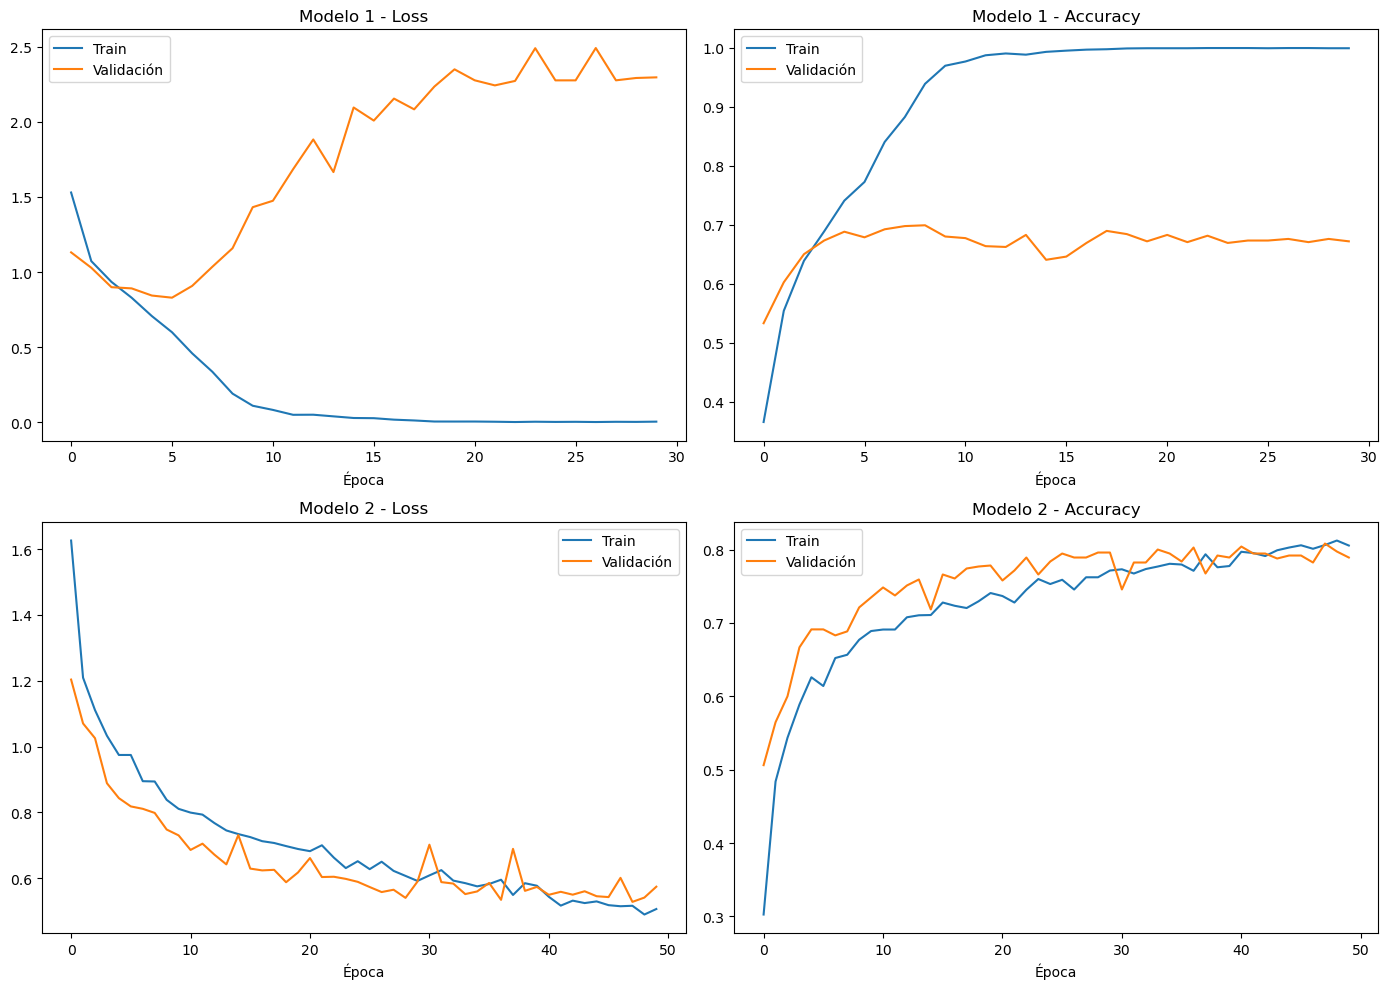

Modelo 1 - Accuracy final validación: 0.6721
Modelo 2 - Accuracy final validación: 0.7891


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Modelo 1
axes[0, 0].plot(history1.history['loss'], label='Train')
axes[0, 0].plot(history1.history['val_loss'], label='Validación')
axes[0, 0].set_title('Modelo 1 - Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].legend()

axes[0, 1].plot(history1.history['accuracy'], label='Train')
axes[0, 1].plot(history1.history['val_accuracy'], label='Validación')
axes[0, 1].set_title('Modelo 1 - Accuracy')
axes[0, 1].set_xlabel('Época')
axes[0, 1].legend()

# Modelo 2
axes[1, 0].plot(history2.history['loss'], label='Train')
axes[1, 0].plot(history2.history['val_loss'], label='Validación')
axes[1, 0].set_title('Modelo 2 - Loss')
axes[1, 0].set_xlabel('Época')
axes[1, 0].legend()

axes[1, 1].plot(history2.history['accuracy'], label='Train')
axes[1, 1].plot(history2.history['val_accuracy'], label='Validación')
axes[1, 1].set_title('Modelo 2 - Accuracy')
axes[1, 1].set_xlabel('Época')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Modelo 1 - Accuracy final validación: {history1.history['val_accuracy'][-1]:.4f}")
print(f"Modelo 2 - Accuracy final validación: {history2.history['val_accuracy'][-1]:.4f}")

**Comparativa Modelo 1 vs Modelo 2:**

La diferencia principal es el grado de overfitting:

- **Modelo 1**: se nota claramente el sobreajuste. La loss de entrenamiento baja continuamente hasta valores muy pequeños mientras que la de validación se estanca o sube. Las curvas de train y validación se separan bastante desde las primeras épocas. El accuracy en train llega casi al 100% pero en validación se queda bastante por debajo.

- **Modelo 2**: las curvas de train y validación se mantienen mucho más juntas. Hay dos efectos visibles: el dropout hace que el accuracy en train sea más bajo (porque durante el entrenamiento se desactivan neuronas), y el data augmentation hace que las imágenes de train sean más variadas. El resultado es que el modelo generaliza mejor, consiguiendo un mejor accuracy en validación aunque aprenda más despacio.

# c) Modelo 3: Transfer Learning (objetivo: accuracy_valid > 88%)

En nuestro problema de clasificación de flores, el utilizar CNNs diseñadas y entrenadas por nosotros mismos, aparece una barrera en las proximidades del 75-77% de precisión del modelo (siempre sobre validación).

Para superar este escollo, el siguiente paso natural es la utilización de modelos preentrenados. Existe una gran variedad de ellos basados en redes CNNs clásicas, donde la principal diferencia es que acumulan más capas que nuestros modelos 1 y 2.

En general, utilizando estos modelos convolucionales preentrenados podemos alcanzar accuracies próximos al 90%. Normalmente, estos modelos han sido previamente entrenados sobre datasets de gran tamaño y con gran número de categorías, como subconjuntos de Imagenet (14 millones de imágenes de 22K categorías).

Para elegir el modelo preentrenado que debe utilizar cada grupo, proceda del siguiente modo:
* Paso 1: sume los DNIs de los componentes del grupo
* Paso 2: Aplique la siguiente operación al resultado anterior: res mod 6.
* Paso 3: Tome el modelo cuyo número asociado coincide con el resultado.

  0. Resnet50 (>90%)
  1. Resnet101 (>90%)
  2. VGG16 (>90%)
  3. VGG19 (>90%)
  4. Xception (>88%)
  5. InceptionV3 (>88%)

**En nuestro caso utilizamos VGG16. Cambiar el modelo según corresponda a vuestro cálculo de DNIs.**

**Tarea 14: Importa el modelo desde Tensorflow**

Dado que este modelo ha sido entrenado para clasificar entre 1.000 categorías, las capas densas finales del modelo no son útiles para nuestro problema de clasificación de 5 categorías (include_top=False). De este modo sólo nos quedamos con la parte que hace la funcionalidad de "procesamiento" de la imagen.

In [25]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

IMG_SIZE_TL = 224  # VGG16 requiere imágenes de 224x224

# Cargamos VGG16 sin las capas densas finales (include_top=False)
# y con los pesos preentrenados en ImageNet
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3)
)

print("Número de capas en VGG16 (sin top):", len(base_model.layers))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Número de capas en VGG16 (sin top): 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

**Tarea 15: Personalizar el bloque de decisión**  
Añadimos una capa de flatten y tres nuevas capas densas especificas para nuestro problema con dimensiones 4096, 1072 y la que necesite la capa de salida (con sus correspondientes drop-outs).

In [26]:
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Tomamos la salida del modelo base y añadimos nuestro bloque de decisión
x = base_model.output
x = Flatten()(x)
x = Dense(4096, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(1072, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model3 = Model(inputs=base_model.input, outputs=output)

print("Total de capas en el modelo completo:", len(model3.layers))

Total de capas en el modelo completo: 25


**Tarea 16: Congelar los pesos que no se vayan a entrenar**

Previo a hacer el denominado `Fine-Tuning` del modelo, indicaremos a Tensorflow que únicamente debe entrenar:

   * Las dos últimas capas convolucionales de la red preentrenada, de las que realizaremos un ajuste fino de los pesos.
   * Las tres capas densas que hemos incluido nuevas.

In [27]:
# Primero congelamos todas las capas del modelo base
for layer in base_model.layers:
    layer.trainable = False

# Luego descongelamos solo las dos últimas capas convolucionales de VGG16
# En VGG16 sin top, las últimas capas conv son block5_conv2 y block5_conv3
for layer in base_model.layers:
    if layer.name in ['block5_conv2', 'block5_conv3']:
        layer.trainable = True

# Las capas densas que añadimos (Flatten, Dense, Dropout, Dense, Dropout, Dense)
# ya son entrenables por defecto al crearlas

# Revisamos qué capas se van a entrenar
print("Capas entrenables:")
for layer in model3.layers:
    if layer.trainable:
        print(f"  {layer.name}")

print(f"\nTotal parámetros entrenables: {sum(tf.size(w).numpy() for w in model3.trainable_weights):,}")

Capas entrenables:
  block5_conv2
  block5_conv3
  flatten_2
  dense_4
  dropout_1
  dense_5
  dropout_2
  dense_6

Total parámetros entrenables: 111,881,509


**Tarea 17: Crear los datagenerators oportunos**

Para ello:
> * Utiliza Data augmentation.  
> * Las imágenes tienen que ser preprocesadas igual que cuando se entrenó el modelo pre-entrenado original. Para ello se utiliza el parámetro `preprocessing_function=preprocess_input`.  
> * Dado que estamos reutilizando un modelo que no "es nuestro", deberemos ceñirnos al tamaño de imagen que permite la red a la entrada: 224x224.

In [28]:
# El preprocess_input de VGG16 centra los canales RGB con las medias de ImageNet
# No hay que poner rescale porque preprocess_input ya lo gestiona

datagen_train_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen_val_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input  # solo preprocesado, sin augmentation
)

train_gen_tl = datagen_train_tl.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32,
    class_mode='sparse'
)

val_gen_tl = datagen_val_tl.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=32,
    class_mode='sparse'
)

Found 2935 images belonging to 5 classes.
Found 735 images belonging to 5 classes.


**Tarea 18: Haz el fine-tuning del modelo con el objetivo de alcanzar un accuracy (sobre el conjunto de validación > 88%).**

A la hora de entrenar un modelo pretrained es típico bajar el learning rate respecto al que utilizaríamos para un modelo nuestro desde cero.

In [ ]:
# Usamos un learning rate bajo para no destrozar los pesos preentrenados
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# EarlyStopping para parar si no mejora y guardar el mejor modelo
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

history3 = model3.fit(
    train_gen_tl,
    epochs=30,
    validation_data=val_gen_tl,
    callbacks=[early_stop]
)

print(f"\nAccuracy final en validación (Modelo 3): {max(history3.history['val_accuracy']):.4f}")

Epoch 1/30
 6/92 ━━━━━━━━━━━━━━━━━━━━ 9:22 7s/step - accuracy: 0.2183 - loss: 20.5164

In [ ]:
# Visualizamos la evolución del entrenamiento del modelo 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history3.history['loss'], label='Train')
ax1.plot(history3.history['val_loss'], label='Validación')
ax1.set_title('Modelo 3 (Transfer Learning) - Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history3.history['accuracy'], label='Train')
ax2.plot(history3.history['val_accuracy'], label='Validación')
ax2.set_title('Modelo 3 (Transfer Learning) - Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nResumen de resultados:")
print(f"  Modelo 1 (CNN básica):        val_accuracy = {max(history1.history['val_accuracy']):.4f}")
print(f"  Modelo 2 (Dropout + Aug):     val_accuracy = {max(history2.history['val_accuracy']):.4f}")
print(f"  Modelo 3 (Transfer Learning): val_accuracy = {max(history3.history['val_accuracy']):.4f}")